<a href="https://colab.research.google.com/github/khalidkhankakar/Hands-on-Machine-Learning/blob/master/training_neural_network/training_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Training Neural Network


### Vanishing and Expolding

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [16]:
import sys
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

In [17]:
if IS_COLAB:
  %pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.2 MB/s eta 0:00:00


In [3]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"

device

'cuda'

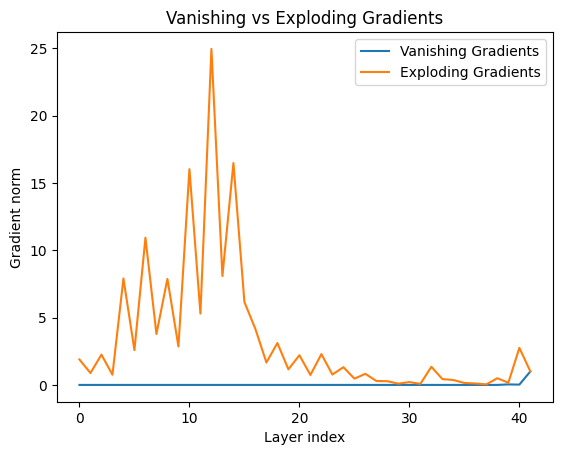

In [4]:
# The problem
class DeepNN(nn.Module):
  def __init__(self, depth=10, width=32):
    super().__init__()

    layers = []
    for _ in range(depth):
      layers.append(nn.Linear(width, width))
      layers.append(nn.Tanh())

    layers.append(nn.Linear(width, 1))

    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)


# Function to track gradient norms
def track_gradients(model, input_tensor):
    output = model(input_tensor)
    loss = output.mean()
    loss.backward()

    grad_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norms.append(param.grad.norm().item())
    return grad_norms

# Settings
depth = 20
width = 10
x = torch.randn(1, width)

# Case 1: Vanishing gradients (small weights)
model_vanish = DeepNN(depth, width)
for p in model_vanish.parameters():
    nn.init.normal_(p, mean=0, std=0.01)

vanish_grads = track_gradients(model_vanish, x)

# Case 2: Exploding gradients (large weights)
model_explode = DeepNN(depth, width)
for p in model_explode.parameters():
    nn.init.normal_(p, mean=0, std=1.5)

explode_grads = track_gradients(model_explode, x)

# Plot
plt.figure()
plt.plot(vanish_grads, label="Vanishing Gradients")
plt.plot(explode_grads, label="Exploding Gradients")
plt.xlabel("Layer index")
plt.ylabel("Gradient norm")
plt.legend()
plt.title("Vanishing vs Exploding Gradients")
plt.show()

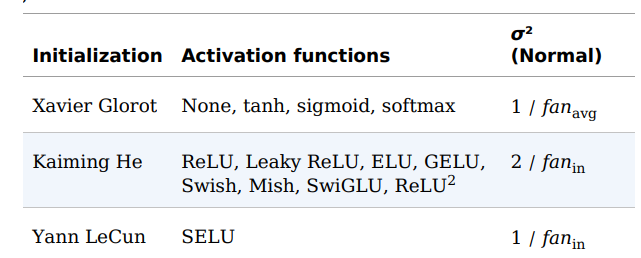

/tmp/ipykernel_10763/1309464284.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


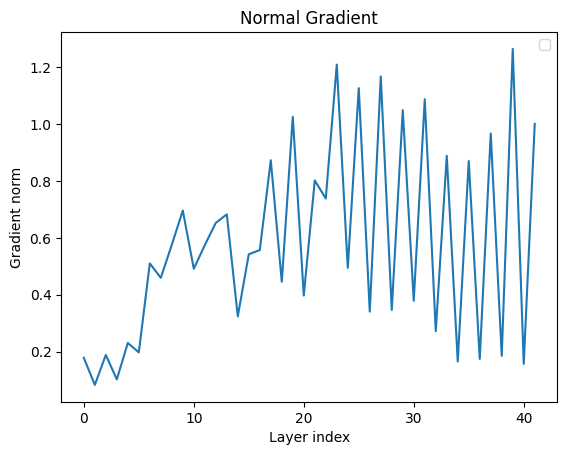

In [5]:
# Solution
model = DeepNN(depth, width)
for name, param in model.named_parameters():
  if 'weight' in name:
    nn.init.xavier_normal_(param)
  else:
    nn.init.zeros_(param)

grads = track_gradients(model, x)
plt.figure()
plt.plot(grads)
plt.xlabel("Layer index")
plt.ylabel("Gradient norm")
plt.legend()
plt.title("Normal Gradient")
plt.show()

# Note
# nn.ReLU + Kaiming
# nn.Tanh() + Xavier

### Leaky ReLU
Having z < 0 ensure that it never actually die but goes in long coma and have chance to eventually wake up.


*   **RReLU**:-  where α is picked randomly in
a given range during training and is fixed to an average value
during testing. RReLU also performed fairly well an
*   **PReLU**:- where α is
authorized to be learned during training: instead of being a
hyperparameter, it becomes a parameter that can be modified
by backpropagation like any other parameter. PReLU was
reported to strongly outperform ReLU on large image datasets,
but on small




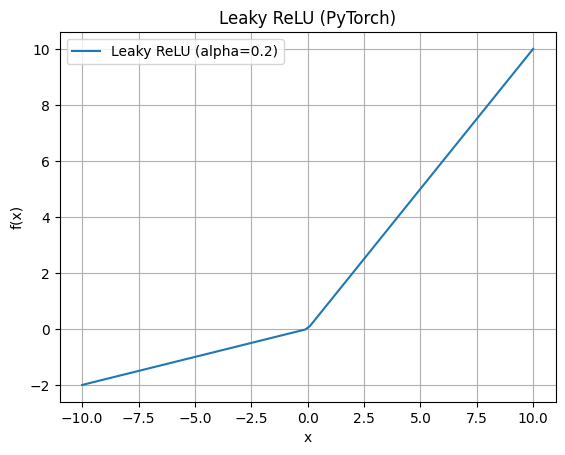

In [6]:
import torch.nn.functional as F

def leaky_relu(x, a):

  return F.leaky_relu(x, negative_slope=a) # torch.where(x > 0, x , x * a)

alpha = 0.2
x = torch.linspace(-10, 10, 100)
y = leaky_relu(x, alpha)

plt.figure()
plt.plot(x, y, label=f"Leaky ReLU (alpha={alpha})")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Leaky ReLU (PyTorch)")
plt.legend()
plt.grid()
plt.show()

### Transfer Learning

In [10]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import fetch_openml


fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
X = torch.FloatTensor(fashion_mnist.data.reshape(-1, 1, 28, 28) / 255.)
y = torch.from_numpy(fashion_mnist.target.astype(int))

In [13]:
in_B = (y == 0) | (y==2)
X_A, y_A = X[~in_B], y[~in_B]
y_A = torch.maximum(y_A - 2, torch.tensor(0))
X_B, y_B = X[in_B], (y[in_B] == 2).to(dtype=torch.float32).view(-1, 1)

In [14]:
train_set_A = TensorDataset(X_A[:-7_000], y_A[:-7_000])
valid_set_A = TensorDataset(X_A[-7_000:-5_000], y_A[-7_000:-5_000])
test_set_A = TensorDataset(X_A[-5_000:], y_A[-5_000:])

train_set_B = TensorDataset(X_B[:20], y_B[:20])
valid_set_B = TensorDataset(X_B[20:5_000], y_B[20:5_000])
test_set_B = TensorDataset(X_B[5_000:], y_B[5_000:])

In [15]:
train_loader_A = DataLoader(train_set_A, batch_size=32, shuffle=True)
valid_loader_A = DataLoader(valid_set_A, batch_size=32)
test_loader_A = DataLoader(test_set_A, batch_size=32)

train_loader_B = DataLoader(train_set_B, batch_size=32, shuffle=True)
valid_loader_B = DataLoader(valid_set_B, batch_size=32)
test_loader_B = DataLoader(test_set_B, batch_size=32)

In [25]:
import torchmetrics
def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)
  return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
  history = {"train_loss": [], "train_metrics":[], "valid_metrics": []}
  for epoch in range(n_epochs):
    total_loss = 0.0
    metric.reset()
    model.train()

    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()

      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)

    history['train_loss'].append(total_loss / len(train_loader))
    history['train_metrics'].append(metric.compute().item())
    history['valid_metrics'].append(evaluate_tm(model, valid_loader, metric).item())
    print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_loss'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
  return history

In [19]:
def use_he_init(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_uniform_(module.weight)
    nn.init.zeros_(module.bias)


In [20]:
torch.manual_seed(42)
model_A = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 8)
)

model_A = model_A.to(device)

In [21]:
model_A.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=8, bias=True)
)

In [26]:
n_epochs = 20
optimizer = torch.optim.SGD(model_A.parameters(), lr=0.005)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(device)
history_A = train(model_A, optimizer, xentropy, accuracy, train_loader_A, valid_loader_A, n_epochs)

Epoch 1/20, train loss: 0.3525, train metric: 0.8790, valid metric: 0.8880
Epoch 2/20, train loss: 0.3054, train metric: 0.8943, valid metric: 0.8975
Epoch 3/20, train loss: 0.2811, train metric: 0.9007, valid metric: 0.8320
Epoch 4/20, train loss: 0.2652, train metric: 0.9073, valid metric: 0.8915
Epoch 5/20, train loss: 0.2519, train metric: 0.9125, valid metric: 0.8950
Epoch 6/20, train loss: 0.2397, train metric: 0.9162, valid metric: 0.8910
Epoch 7/20, train loss: 0.2317, train metric: 0.9194, valid metric: 0.9075
Epoch 8/20, train loss: 0.2234, train metric: 0.9224, valid metric: 0.9015
Epoch 9/20, train loss: 0.2149, train metric: 0.9248, valid metric: 0.9040
Epoch 10/20, train loss: 0.2098, train metric: 0.9276, valid metric: 0.9150
Epoch 11/20, train loss: 0.2029, train metric: 0.9286, valid metric: 0.8985
Epoch 12/20, train loss: 0.1982, train metric: 0.9305, valid metric: 0.9210
Epoch 13/20, train loss: 0.1929, train metric: 0.9320, valid metric: 0.9185
Epoch 14/20, train lo

In [27]:
torch.manual_seed(9)

model_B = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
).to(device)

In [28]:
model_B.apply(use_he_init)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=100, bias=True)
  (2): ReLU()
  (3): Linear(in_features=100, out_features=100, bias=True)
  (4): ReLU()
  (5): Linear(in_features=100, out_features=100, bias=True)
  (6): ReLU()
  (7): Linear(in_features=100, out_features=1, bias=True)
)

In [30]:
optimizer = torch.optim.SGD(model_B.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task='binary').to(device)
history_B = train(model_B, optimizer, xentropy, accuracy, train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 1.1117, train metric: 0.4000, valid metric: 0.4970
Epoch 2/20, train loss: 0.9995, train metric: 0.6000, valid metric: 0.4970
Epoch 3/20, train loss: 0.8812, train metric: 0.6000, valid metric: 0.4970
Epoch 4/20, train loss: 0.7885, train metric: 0.6000, valid metric: 0.4970
Epoch 5/20, train loss: 0.7171, train metric: 0.6000, valid metric: 0.4970
Epoch 6/20, train loss: 0.6597, train metric: 0.6000, valid metric: 0.4970
Epoch 7/20, train loss: 0.6151, train metric: 0.6000, valid metric: 0.4976
Epoch 8/20, train loss: 0.5828, train metric: 0.6000, valid metric: 0.4980
Epoch 9/20, train loss: 0.5573, train metric: 0.6000, valid metric: 0.4988
Epoch 10/20, train loss: 0.5376, train metric: 0.6000, valid metric: 0.5012
Epoch 11/20, train loss: 0.5217, train metric: 0.6000, valid metric: 0.5048
Epoch 12/20, train loss: 0.5083, train metric: 0.6000, valid metric: 0.5122
Epoch 13/20, train loss: 0.4972, train metric: 0.6500, valid metric: 0.5227
Epoch 14/20, train lo

In [31]:
evaluate_tm(model_B, test_loader_B, accuracy)

tensor(0.6948, device='cuda:0')

Actual Tansfer learning


In [32]:
import copy
torch.manual_seed(43)
reused_layers = copy.deepcopy(model_A[:-1])
model_B_on_A = nn.Sequential(
    *reused_layers,
    nn.Linear(100,1)
).to(device)

In [33]:
for layer in model_B_on_A[:-1]:
  for param in layer.parameters():
    param.requires_grad = False


In [34]:
n_epochs = 20
optimizer = torch.optim.SGD(model_B_on_A.parameters(), lr=0.005)
xentropy = nn.BCEWithLogitsLoss()
accuracy = torchmetrics.Accuracy(task="binary").to(device)
history_B = train(model_B_on_A, optimizer, xentropy, accuracy,
                  train_loader_B, valid_loader_B, n_epochs)

Epoch 1/20, train loss: 0.9179, train metric: 0.4000, valid metric: 0.4675
Epoch 2/20, train loss: 0.8060, train metric: 0.3000, valid metric: 0.4743
Epoch 3/20, train loss: 0.7492, train metric: 0.2000, valid metric: 0.5671
Epoch 4/20, train loss: 0.7162, train metric: 0.4500, valid metric: 0.6157
Epoch 5/20, train loss: 0.6928, train metric: 0.5500, valid metric: 0.6371
Epoch 6/20, train loss: 0.6733, train metric: 0.6500, valid metric: 0.6448
Epoch 7/20, train loss: 0.6556, train metric: 0.7000, valid metric: 0.6622
Epoch 8/20, train loss: 0.6392, train metric: 0.7000, valid metric: 0.6795
Epoch 9/20, train loss: 0.6235, train metric: 0.7500, valid metric: 0.7000
Epoch 10/20, train loss: 0.6086, train metric: 0.7500, valid metric: 0.7205
Epoch 11/20, train loss: 0.5944, train metric: 0.7500, valid metric: 0.7434
Epoch 12/20, train loss: 0.5807, train metric: 0.7500, valid metric: 0.7631
Epoch 13/20, train loss: 0.5677, train metric: 0.7500, valid metric: 0.7809
Epoch 14/20, train lo

In [35]:
evaluate_tm(model_B_on_A, test_loader_B, accuracy)

tensor(0.8786, device='cuda:0')